In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_zomato.csv")
print(f"Rows: {len(df):,}")
df.head()

Rows: 101,530


,restaurant_name,dining_rating,delivery_rating,dining_votes,delivery_votes,cuisine,place_name,city,item_name,best_seller,votes,prices,rating_gap,avg_item_votes
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0,-0.3,22.909042
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0,-0.3,22.909042
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0,-0.3,22.909042
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0,-0.3,22.909042
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0,-0.3,22.909042


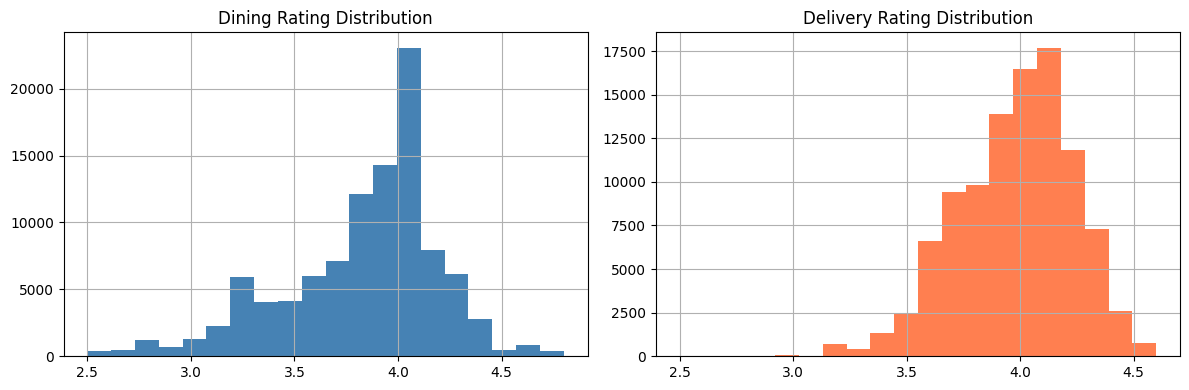

In [ ]:
# Rating distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["dining_rating"].hist(ax=axes[0], bins=20, color="steelblue")
axes[0].set_title("Dining Rating Distribution")

df["delivery_rating"].hist(ax=axes[1], bins=20, color="coral")
axes[1].set_title("Delivery Rating Distribution")

plt.tight_layout()
# plt.savefig("../reports/fig_01_rating_distributions.png")
plt.show()

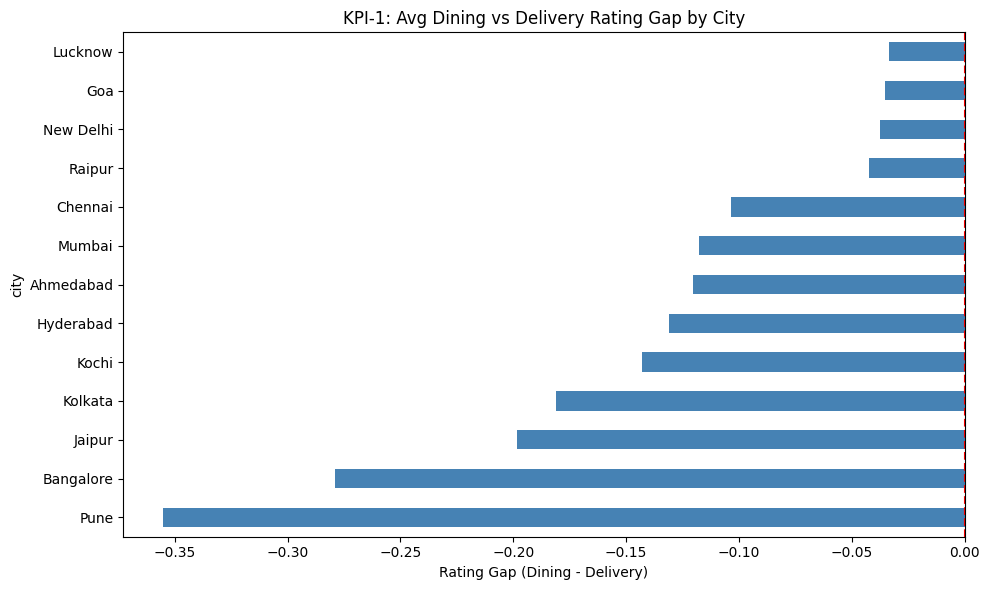

In [ ]:
# KPI-1: Rating gap by city

restaurant_df = df.drop_duplicates(subset=["restaurant_name", "city"])
city_gap = restaurant_df.groupby("city")["rating_gap"].mean().sort_values()

city_gap.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("KPI-1: Avg Dining vs Delivery Rating Gap by City")
plt.xlabel("Rating Gap (Dining - Delivery)")
plt.axvline(0, color="red", linestyle="--")
plt.tight_layout()
# plt.savefig("../reports/fig_02_kpi1_city_gap.png")
plt.show()

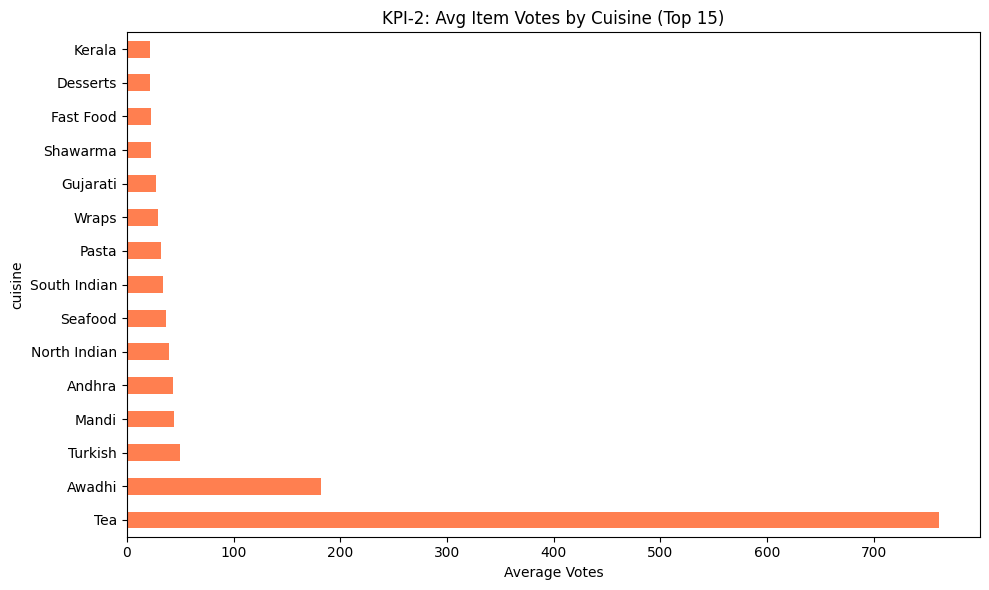

In [ ]:
# KPI-2: Avg votes by cuisine (top 15)

top_cuisines = df.groupby("cuisine")["votes"].mean().sort_values(ascending=False).head(15)

top_cuisines.plot(kind="barh", figsize=(10, 6), color="coral")
plt.title("KPI-2: Avg Item Votes by Cuisine (Top 15)")
plt.xlabel("Average Votes")
plt.tight_layout()
# plt.savefig("../reports/fig_03_kpi2_cuisine_votes.png")
plt.show()

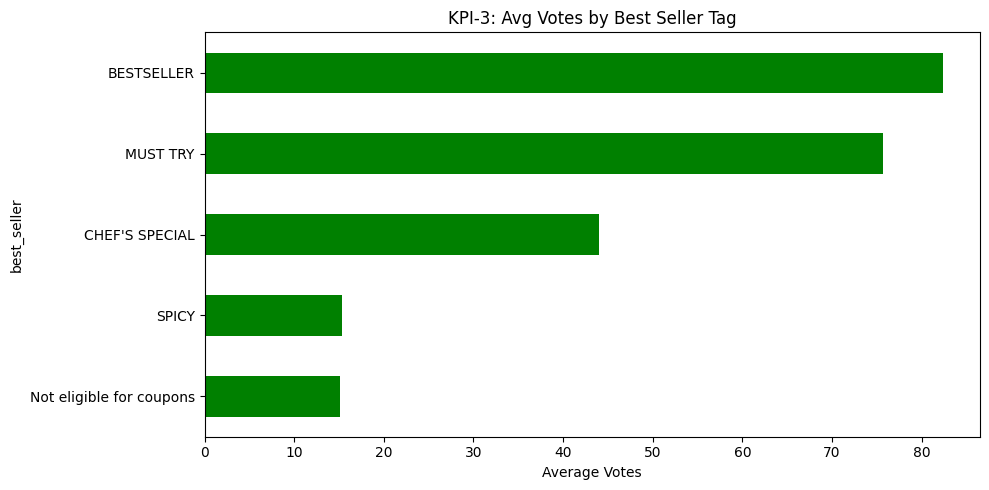

In [ ]:
#Best seller impact

top_tags = df["best_seller"].value_counts().head(5).index
df_top = df[df["best_seller"].isin(top_tags)]

df_top.groupby("best_seller")["votes"].mean().sort_values().plot(kind="barh", figsize=(10, 5), color="green")
plt.title("KPI-3: Avg Votes by Best Seller Tag")
plt.xlabel("Average Votes")
plt.tight_layout()
# plt.savefig("../reports/fig_04_kpi3_bestseller_votes.png")
plt.show()

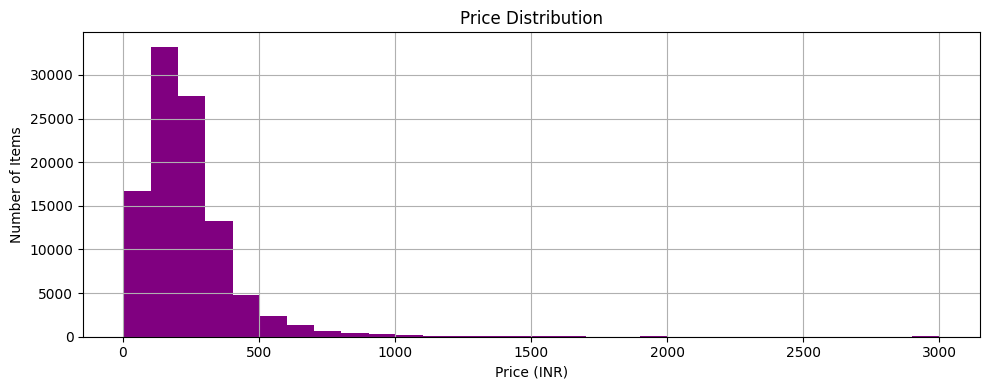

In [ ]:
# Price distribution

df["prices"].hist(bins=30, figsize=(10, 4), color="purple")
plt.title("Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Items")
plt.tight_layout()
# plt.savefig("../reports/fig_05_price_distribution.png")
plt.show()